In [1]:
print("helloworld")

helloworld


In [1]:
cd dataset_generator/

/home/amarjithtk/acoder/finalyear-project-rev2/dataset_generator


In [12]:
!python3 train_lstm.py

Loading dataset...
Dataset shape after filtering: (48216, 12)
Scaling Data...
Starting training (epochs)...
Epoch [1/30], Loss: 0.004727
Epoch [2/30], Loss: 0.002138
Epoch [3/30], Loss: 0.002086
Epoch [4/30], Loss: 0.002051
Epoch [5/30], Loss: 0.002044
Epoch [6/30], Loss: 0.002022
Epoch [7/30], Loss: 0.002009
Epoch [8/30], Loss: 0.002006
Epoch [9/30], Loss: 0.001987
Epoch [10/30], Loss: 0.001981
Epoch [11/30], Loss: 0.001969
Epoch [12/30], Loss: 0.001970
Epoch [13/30], Loss: 0.001966
Epoch [14/30], Loss: 0.001959
Epoch [15/30], Loss: 0.001953
Epoch [16/30], Loss: 0.001950
Epoch [17/30], Loss: 0.001952
Epoch [18/30], Loss: 0.001946
Epoch [19/30], Loss: 0.001944
Epoch [20/30], Loss: 0.001941
Epoch [21/30], Loss: 0.001930
Epoch [22/30], Loss: 0.001933
Epoch [23/30], Loss: 0.001935
Epoch [24/30], Loss: 0.001927
Epoch [25/30], Loss: 0.001925
Epoch [26/30], Loss: 0.001920
Epoch [27/30], Loss: 0.001915
Epoch [28/30], Loss: 0.001912
Epoch [29/30], Loss: 0.001914
Epoch [30/30], Loss: 0.001908



In [13]:
!python train_cnn_lstm.py

Loading dataset...
Dataset shape after filtering: (48216, 12)
Scaling Data...
Starting training (epochs)...
Epoch [1/30], Loss: 0.004443
Epoch [2/30], Loss: 0.002139
Epoch [3/30], Loss: 0.002087
Epoch [4/30], Loss: 0.002062
Epoch [5/30], Loss: 0.002036
Epoch [6/30], Loss: 0.002017
Epoch [7/30], Loss: 0.002007
Epoch [8/30], Loss: 0.001993
Epoch [9/30], Loss: 0.001992
Epoch [10/30], Loss: 0.001977
Epoch [11/30], Loss: 0.001978
Epoch [12/30], Loss: 0.001969
Epoch [13/30], Loss: 0.001965
Epoch [14/30], Loss: 0.001964
Epoch [15/30], Loss: 0.001956
Epoch [16/30], Loss: 0.001952
Epoch [17/30], Loss: 0.001949
Epoch [18/30], Loss: 0.001947
Epoch [19/30], Loss: 0.001942
Epoch [20/30], Loss: 0.001937
Epoch [21/30], Loss: 0.001937
Epoch [22/30], Loss: 0.001934
Epoch [23/30], Loss: 0.001926
Epoch [24/30], Loss: 0.001924
Epoch [25/30], Loss: 0.001922
Epoch [26/30], Loss: 0.001921
Epoch [27/30], Loss: 0.001913
Epoch [28/30], Loss: 0.001912
Epoch [29/30], Loss: 0.001906
Epoch [30/30], Loss: 0.001902



In [14]:
!python train_cnn_lstm_xgb.py

Loading dataset...
Dataset shape after filtering: (48216, 12)
Scaling Data...
Stage 1: Training CNN-LSTM...
Epoch [1/30], Loss: 0.004348
Epoch [2/30], Loss: 0.002142
Epoch [3/30], Loss: 0.002094
Epoch [4/30], Loss: 0.002063
Epoch [5/30], Loss: 0.002043
Epoch [6/30], Loss: 0.002027
Epoch [7/30], Loss: 0.002022
Epoch [8/30], Loss: 0.002010
Epoch [9/30], Loss: 0.001996
Epoch [10/30], Loss: 0.001985
Epoch [11/30], Loss: 0.001978
Epoch [12/30], Loss: 0.001972
Epoch [13/30], Loss: 0.001965
Epoch [14/30], Loss: 0.001958
Epoch [15/30], Loss: 0.001958
Epoch [16/30], Loss: 0.001948
Epoch [17/30], Loss: 0.001953
Epoch [18/30], Loss: 0.001941
Epoch [19/30], Loss: 0.001940
Epoch [20/30], Loss: 0.001938
Epoch [21/30], Loss: 0.001938
Epoch [22/30], Loss: 0.001929
Epoch [23/30], Loss: 0.001926
Epoch [24/30], Loss: 0.001927
Epoch [25/30], Loss: 0.001925
Epoch [26/30], Loss: 0.001922
Epoch [27/30], Loss: 0.001918
Epoch [28/30], Loss: 0.001913
Epoch [29/30], Loss: 0.001912
Epoch [30/30], Loss: 0.001907
E

## Additional Prediction Visualizations

These plots reuse the trained LSTM model and scaler to inspect prediction quality from multiple angles: target-wise trends, residual patterns, hourly error structure, actual-vs-predicted fit, and daily load/generation balance.

In [23]:
import os
from pathlib import Path
os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib-cache")

import joblib
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.metrics import mean_absolute_error, mean_squared_error

plt.rcParams["figure.dpi"] = 120
plt.style.use("seaborn-v0_8-whitegrid" if "seaborn-v0_8-whitegrid" in plt.style.available else "default")

DATA_DIR = Path("dataset_generator") if Path("dataset_generator").exists() else Path(".")
DATA_FILE = DATA_DIR / "kerala_microgrid_hourly_dataset.csv"
MODEL_FILE = DATA_DIR / "lstm_model.pth"
SCALER_FILE = DATA_DIR / "scaler.joblib"
SEQ_LENGTH = 24
HIDDEN_SIZE = 64
NUM_LAYERS = 2

features = ["temperature", "humidity", "wind_speed", "cloud_cover", "solar_irradiance"]
targets = ["residential_load_MW", "commercial_load_MW", "industrial_load_MW", "solar_MW", "wind_MW"]

class MicrogridLSTM(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_size):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :])

def create_sequences(data, seq_length, num_targets):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i + seq_length, :])
        y.append(data[i + seq_length, -num_targets:])
    return np.array(X), np.array(y)

df = pd.read_csv(DATA_FILE, parse_dates=["timestamp"]).sort_values("timestamp").reset_index(drop=True)
scaler = joblib.load(SCALER_FILE)
scaled_data = scaler.transform(df[features + targets].values)

X, y_scaled = create_sequences(scaled_data, SEQ_LENGTH, len(targets))
train_size = int(len(X) * 0.8)
X_test = torch.FloatTensor(X[train_size:])
test_dates = df["timestamp"].iloc[train_size + SEQ_LENGTH:].reset_index(drop=True)

model = MicrogridLSTM(
    input_size=len(features) + len(targets),
    hidden_size=HIDDEN_SIZE,
    num_layers=NUM_LAYERS,
    output_size=len(targets),
)
model.load_state_dict(torch.load(MODEL_FILE, map_location="cpu"))
model.eval()

with torch.no_grad():
    preds_scaled = model(X_test).numpy()

actuals_dummy = np.zeros((len(X_test), len(features) + len(targets)))
preds_dummy = np.zeros_like(actuals_dummy)
actuals_dummy[:, -len(targets):] = scaled_data[train_size + SEQ_LENGTH:, -len(targets):]
preds_dummy[:, -len(targets):] = preds_scaled

actuals = scaler.inverse_transform(actuals_dummy)[:, -len(targets):]
preds = scaler.inverse_transform(preds_dummy)[:, -len(targets):]
errors = preds - actuals

pred_df = pd.DataFrame({"timestamp": test_dates})
for idx, target in enumerate(targets):
    pred_df[f"actual_{target}"] = actuals[:, idx]
    pred_df[f"pred_{target}"] = preds[:, idx]
    pred_df[f"error_{target}"] = errors[:, idx]
    pred_df[f"abs_error_{target}"] = np.abs(errors[:, idx])

pred_df["hour"] = pred_df["timestamp"].dt.hour
pred_df["day_name"] = pred_df["timestamp"].dt.day_name()
pred_df["date"] = pred_df["timestamp"].dt.date
metrics = pd.DataFrame(
    [
        {
            "target": target.replace("_MW", "").replace("_", " ").title(),
            "MAE": mean_absolute_error(actuals[:, i], preds[:, i]),
            "RMSE": np.sqrt(mean_squared_error(actuals[:, i], preds[:, i])),
        }
        for i, target in enumerate(targets)
    ]
)
metrics

,target,MAE,RMSE
0,Residential Load,0.038861,0.060484
1,Commercial Load,0.011173,0.017548
2,Industrial Load,0.021796,0.038847
3,Solar,0.009471,0.022773
4,Wind,0.000016,0.000078


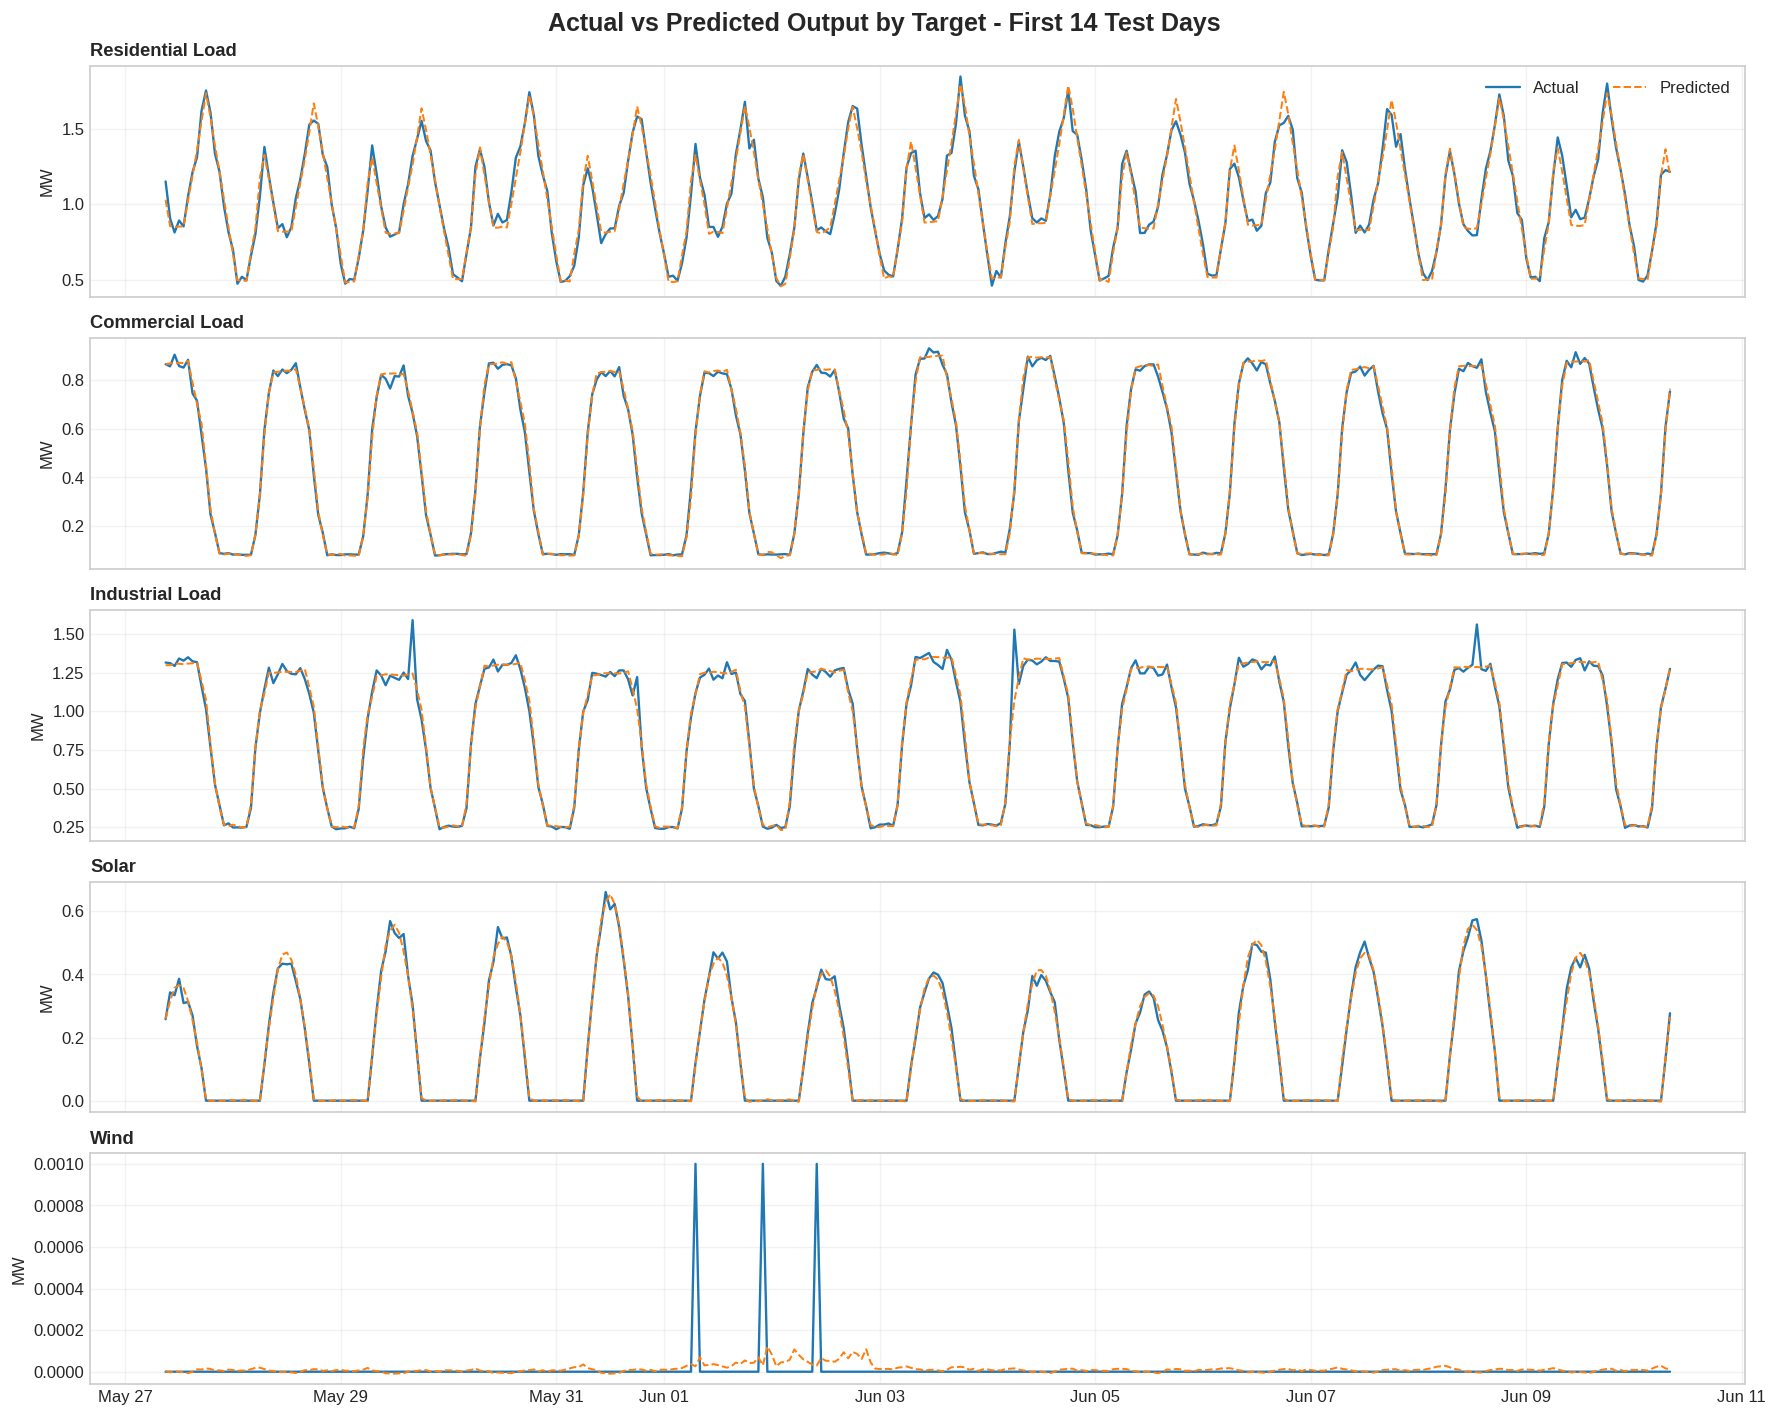

In [31]:
# Target-wise actual vs predicted curves for the first 14 days of the test set
window_hours = 14 * 24
plot_df = pred_df.iloc[:window_hours]

fig, axes = plt.subplots(len(targets), 1, figsize=(15, 12), sharex=True)
for ax, target in zip(axes, targets):
    label = target.replace("_MW", "").replace("_", " ").title()
    ax.plot(plot_df["timestamp"], plot_df[f"actual_{target}"], color="#1f77b4", linewidth=1.4, label="Actual")
    ax.plot(plot_df["timestamp"], plot_df[f"pred_{target}"], color="#ff7f0e", linewidth=1.2, linestyle="--", label="Predicted")
    ax.set_ylabel("MW")
    ax.set_title(label, loc="left", fontsize=11, fontweight="bold")
    ax.grid(alpha=0.25)
axes[0].legend(ncol=2, loc="upper right")
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
fig.suptitle("Actual vs Predicted Output by Target - First 14 Test Days", fontsize=15, fontweight="bold")
fig.tight_layout()
plt.show()

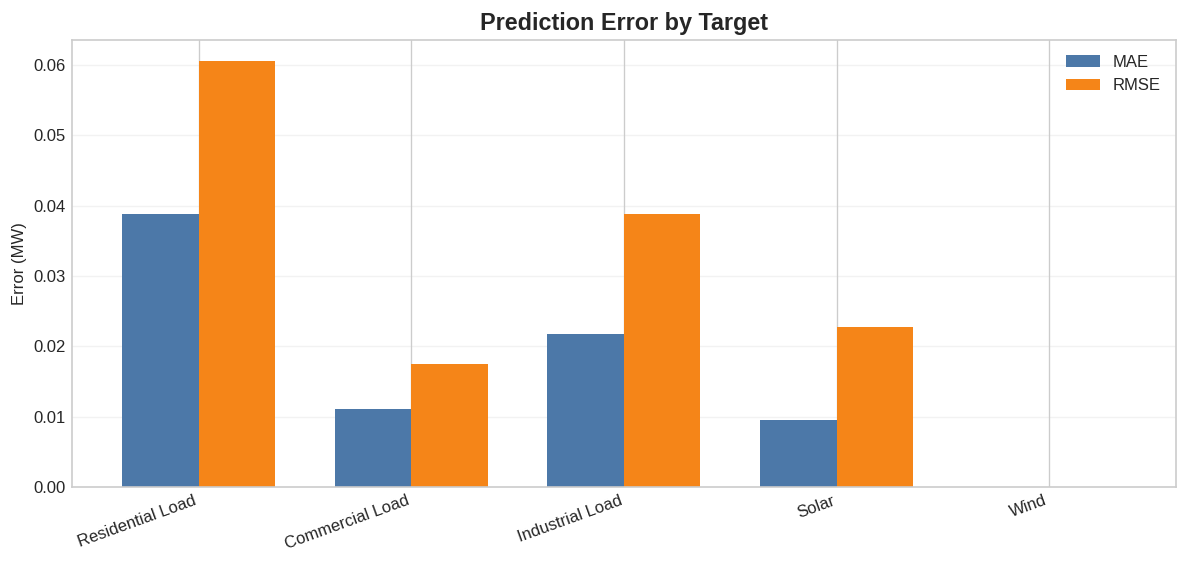

In [32]:
# MAE and RMSE comparison across all predicted targets
fig, ax = plt.subplots(figsize=(10, 4.8))
x = np.arange(len(metrics))
width = 0.36
ax.bar(x - width / 2, metrics["MAE"], width, label="MAE", color="#4c78a8")
ax.bar(x + width / 2, metrics["RMSE"], width, label="RMSE", color="#f58518")
ax.set_title("Prediction Error by Target", fontsize=14, fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels(metrics["target"], rotation=20, ha="right")
ax.set_ylabel("Error (MW)")
ax.legend()
ax.grid(axis="y", alpha=0.25)
fig.tight_layout()
plt.show()

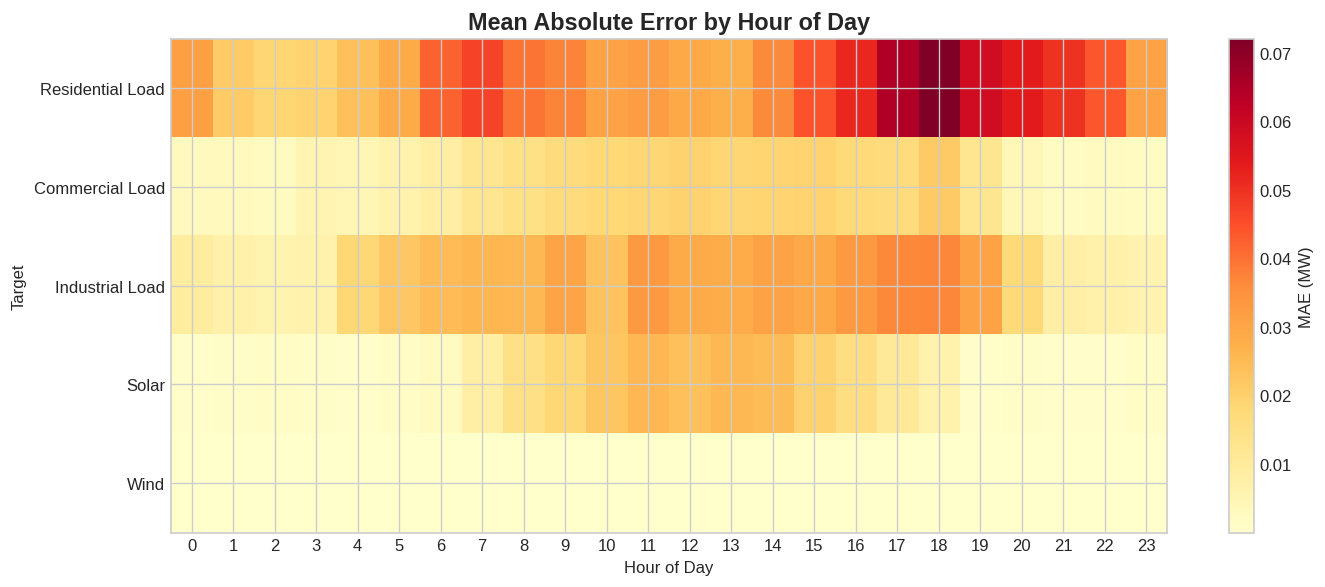

In [33]:
# Hour-of-day error heatmap: useful for finding daily timing bias
hourly_mae = pred_df.groupby("hour")[[f"abs_error_{target}" for target in targets]].mean()
hourly_mae.columns = [target.replace("_MW", "").replace("_", " " ).title() for target in targets]

fig, ax = plt.subplots(figsize=(12, 5))
image = ax.imshow(hourly_mae.T.values, aspect="auto", cmap="YlOrRd")
ax.set_title("Mean Absolute Error by Hour of Day", fontsize=14, fontweight="bold")
ax.set_xlabel("Hour of Day")
ax.set_ylabel("Target")
ax.set_xticks(np.arange(len(hourly_mae.index)))
ax.set_xticklabels(hourly_mae.index)
ax.set_yticks(np.arange(len(hourly_mae.columns)))
ax.set_yticklabels(hourly_mae.columns)
cbar = fig.colorbar(image, ax=ax)
cbar.set_label("MAE (MW)")
fig.tight_layout()
plt.show()

/tmp/ipykernel_7935/515408377.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = ax.boxplot(residual_arrays, labels=residual_labels, showfliers=False, patch_artist=True)


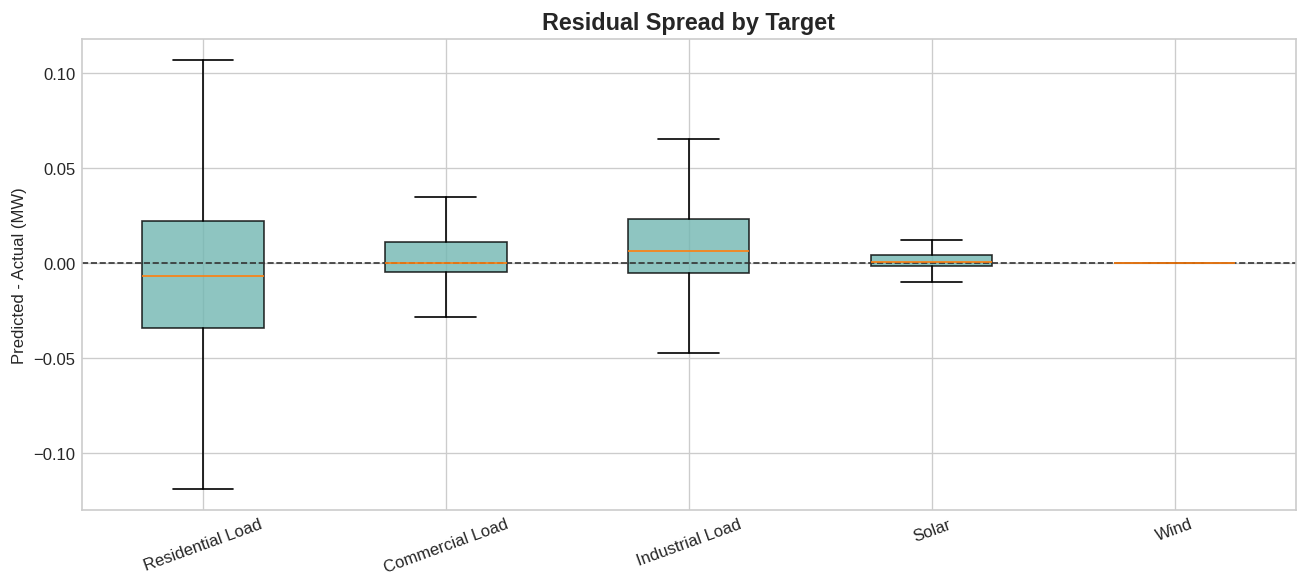

In [34]:
# Residual distributions: centered residuals mean fewer systematic over/under predictions
residual_arrays = [pred_df[f"error_{target}"] for target in targets]
residual_labels = [target.replace("_MW", "").replace("_", " " ).title() for target in targets]

fig, ax = plt.subplots(figsize=(11, 5))
box = ax.boxplot(residual_arrays, labels=residual_labels, showfliers=False, patch_artist=True)
for patch in box["boxes"]:
    patch.set_facecolor("#72b7b2")
    patch.set_alpha(0.8)
ax.axhline(0, color="#333333", linewidth=1, linestyle="--")
ax.set_title("Residual Spread by Target", fontsize=14, fontweight="bold")
ax.set_ylabel("Predicted - Actual (MW)")
ax.tick_params(axis="x", rotation=20)
fig.tight_layout()
plt.show()

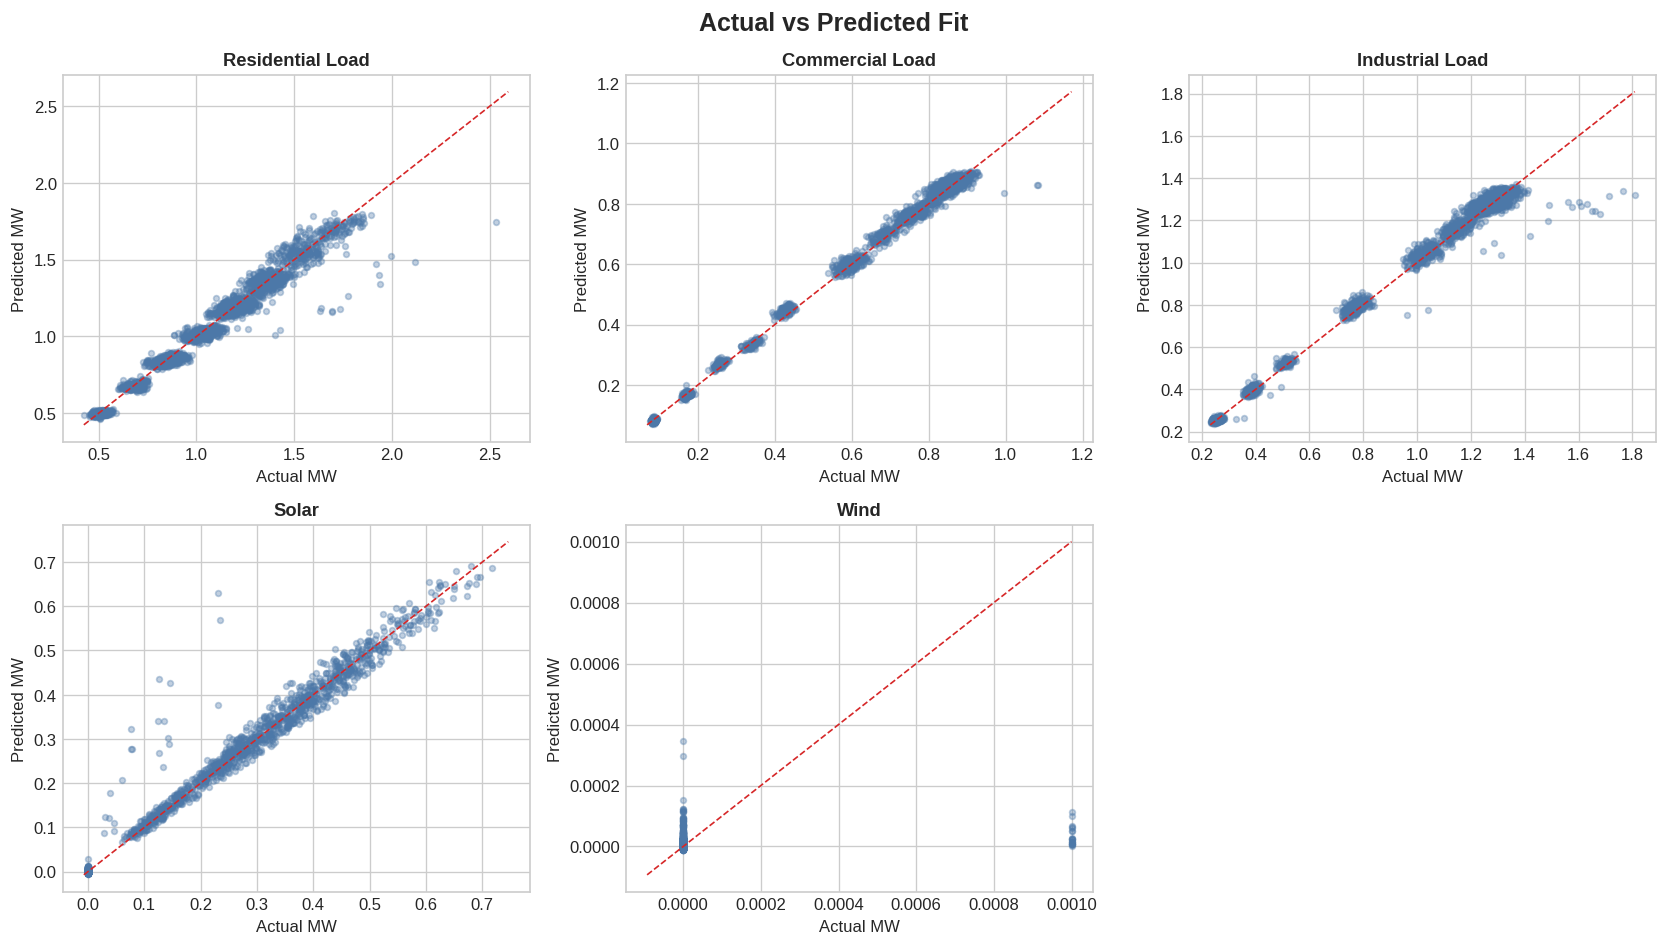

In [35]:
# Actual-vs-predicted scatter plots. The dashed line is a perfect prediction.
sample_df = pred_df.sample(min(2500, len(pred_df)), random_state=42)
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.ravel()
for ax, target in zip(axes, targets):
    actual_col = f"actual_{target}"
    pred_col = f"pred_{target}"
    ax.scatter(sample_df[actual_col], sample_df[pred_col], s=12, alpha=0.35, color="#4c78a8")
    lo = min(pred_df[actual_col].min(), pred_df[pred_col].min())
    hi = max(pred_df[actual_col].max(), pred_df[pred_col].max())
    ax.plot([lo, hi], [lo, hi], color="#d62728", linestyle="--", linewidth=1)
    ax.set_title(target.replace("_MW", "").replace("_", " " ).title(), fontsize=11, fontweight="bold")
    ax.set_xlabel("Actual MW")
    ax.set_ylabel("Predicted MW")
axes[-1].axis("off")
fig.suptitle("Actual vs Predicted Fit", fontsize=15, fontweight="bold")
fig.tight_layout()
plt.show()

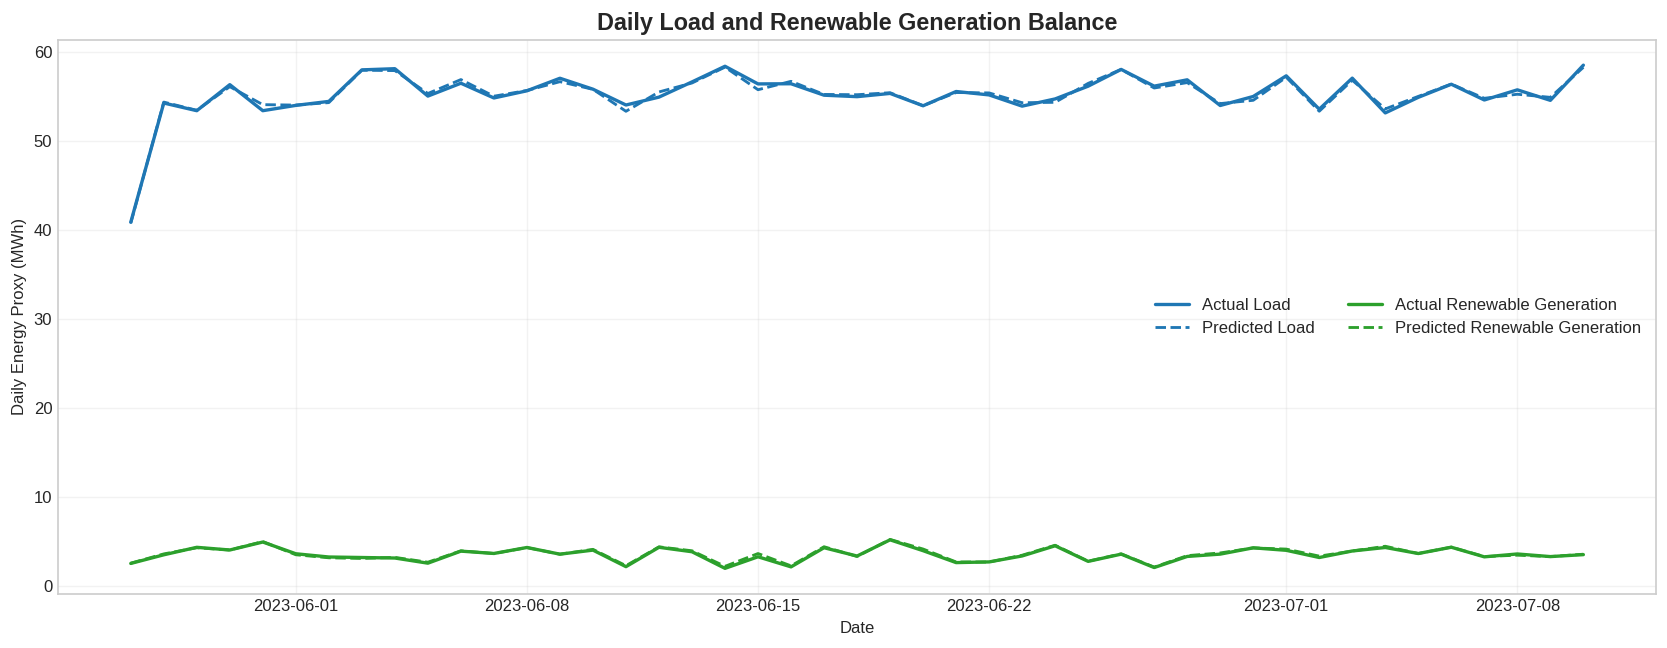

In [36]:
# Daily system balance: total load vs renewable generation from actual data and model predictions
load_targets = ["residential_load_MW", "commercial_load_MW", "industrial_load_MW"]
generation_targets = ["solar_MW", "wind_MW"]

balance_df = pred_df.copy()
balance_df["actual_total_load_MW"] = balance_df[[f"actual_{target}" for target in load_targets]].sum(axis=1)
balance_df["pred_total_load_MW"] = balance_df[[f"pred_{target}" for target in load_targets]].sum(axis=1)
balance_df["actual_renewable_MW"] = balance_df[[f"actual_{target}" for target in generation_targets]].sum(axis=1)
balance_df["pred_renewable_MW"] = balance_df[[f"pred_{target}" for target in generation_targets]].sum(axis=1)
daily_balance = balance_df.groupby("date")[["actual_total_load_MW", "pred_total_load_MW", "actual_renewable_MW", "pred_renewable_MW"]].sum().reset_index().head(45)
daily_balance["date"] = pd.to_datetime(daily_balance["date"])

fig, ax = plt.subplots(figsize=(14, 5.5))
ax.plot(daily_balance["date"], daily_balance["actual_total_load_MW"], label="Actual Load", color="#1f77b4", linewidth=2)
ax.plot(daily_balance["date"], daily_balance["pred_total_load_MW"], label="Predicted Load", color="#1f77b4", linestyle="--", linewidth=1.7)
ax.plot(daily_balance["date"], daily_balance["actual_renewable_MW"], label="Actual Renewable Generation", color="#2ca02c", linewidth=2)
ax.plot(daily_balance["date"], daily_balance["pred_renewable_MW"], label="Predicted Renewable Generation", color="#2ca02c", linestyle="--", linewidth=1.7)
ax.set_title("Daily Load and Renewable Generation Balance", fontsize=14, fontweight="bold")
ax.set_ylabel("Daily Energy Proxy (MWh)")
ax.set_xlabel("Date")
ax.legend(ncol=2)
ax.grid(alpha=0.25)
fig.tight_layout()
plt.show()

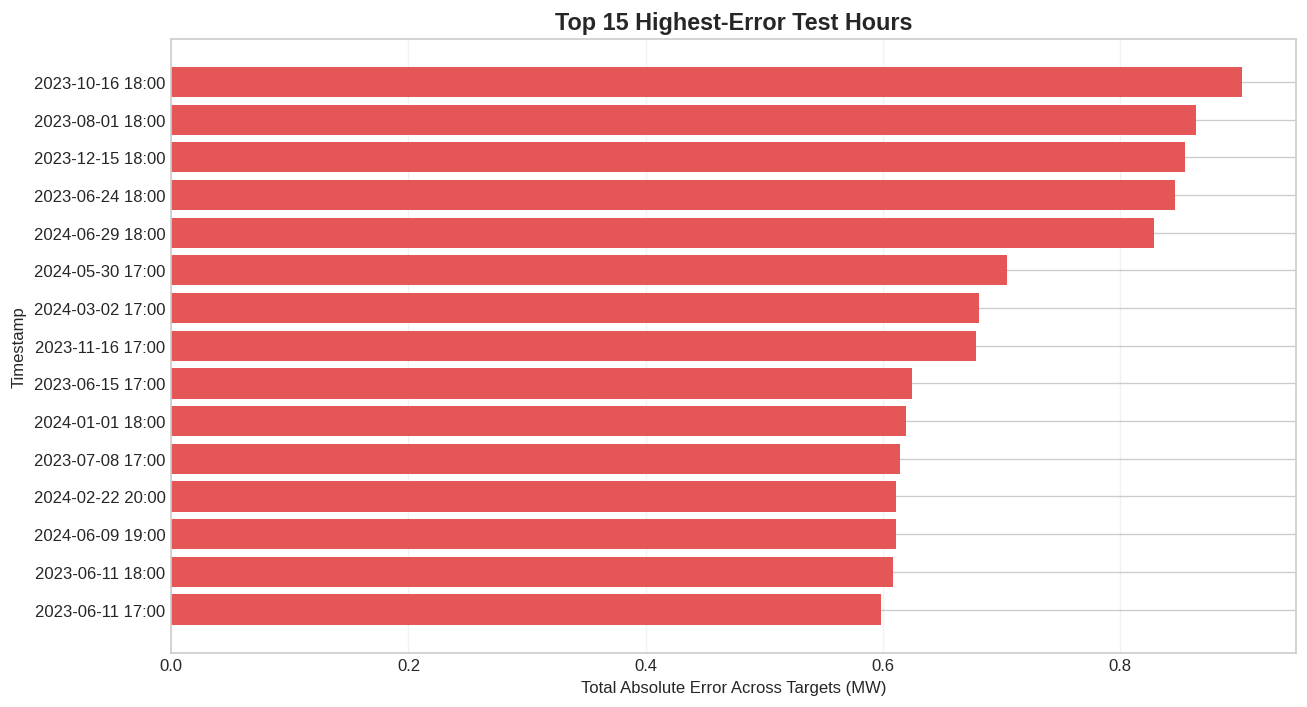

In [37]:
# Largest anomaly misses, ranked by total absolute error across all targets
abs_error_cols = [f"abs_error_{target}" for target in targets]
top_error_df = pred_df.copy()
top_error_df["total_abs_error_MW"] = top_error_df[abs_error_cols].sum(axis=1)
top_error_df = top_error_df.nlargest(15, "total_abs_error_MW").sort_values("total_abs_error_MW")

fig, ax = plt.subplots(figsize=(11, 6))
ax.barh(top_error_df["timestamp"].dt.strftime("%Y-%m-%d %H:%M"), top_error_df["total_abs_error_MW"], color="#e45756")
ax.set_title("Top 15 Highest-Error Test Hours", fontsize=14, fontweight="bold")
ax.set_xlabel("Total Absolute Error Across Targets (MW)")
ax.set_ylabel("Timestamp")
ax.grid(axis="x", alpha=0.25)
fig.tight_layout()
plt.show()